## Opening model at close1 prices — simulation and plot
Run the cell below directly. It loads inputs, runs the requested Kelly parameters, and displays and saves the plot.

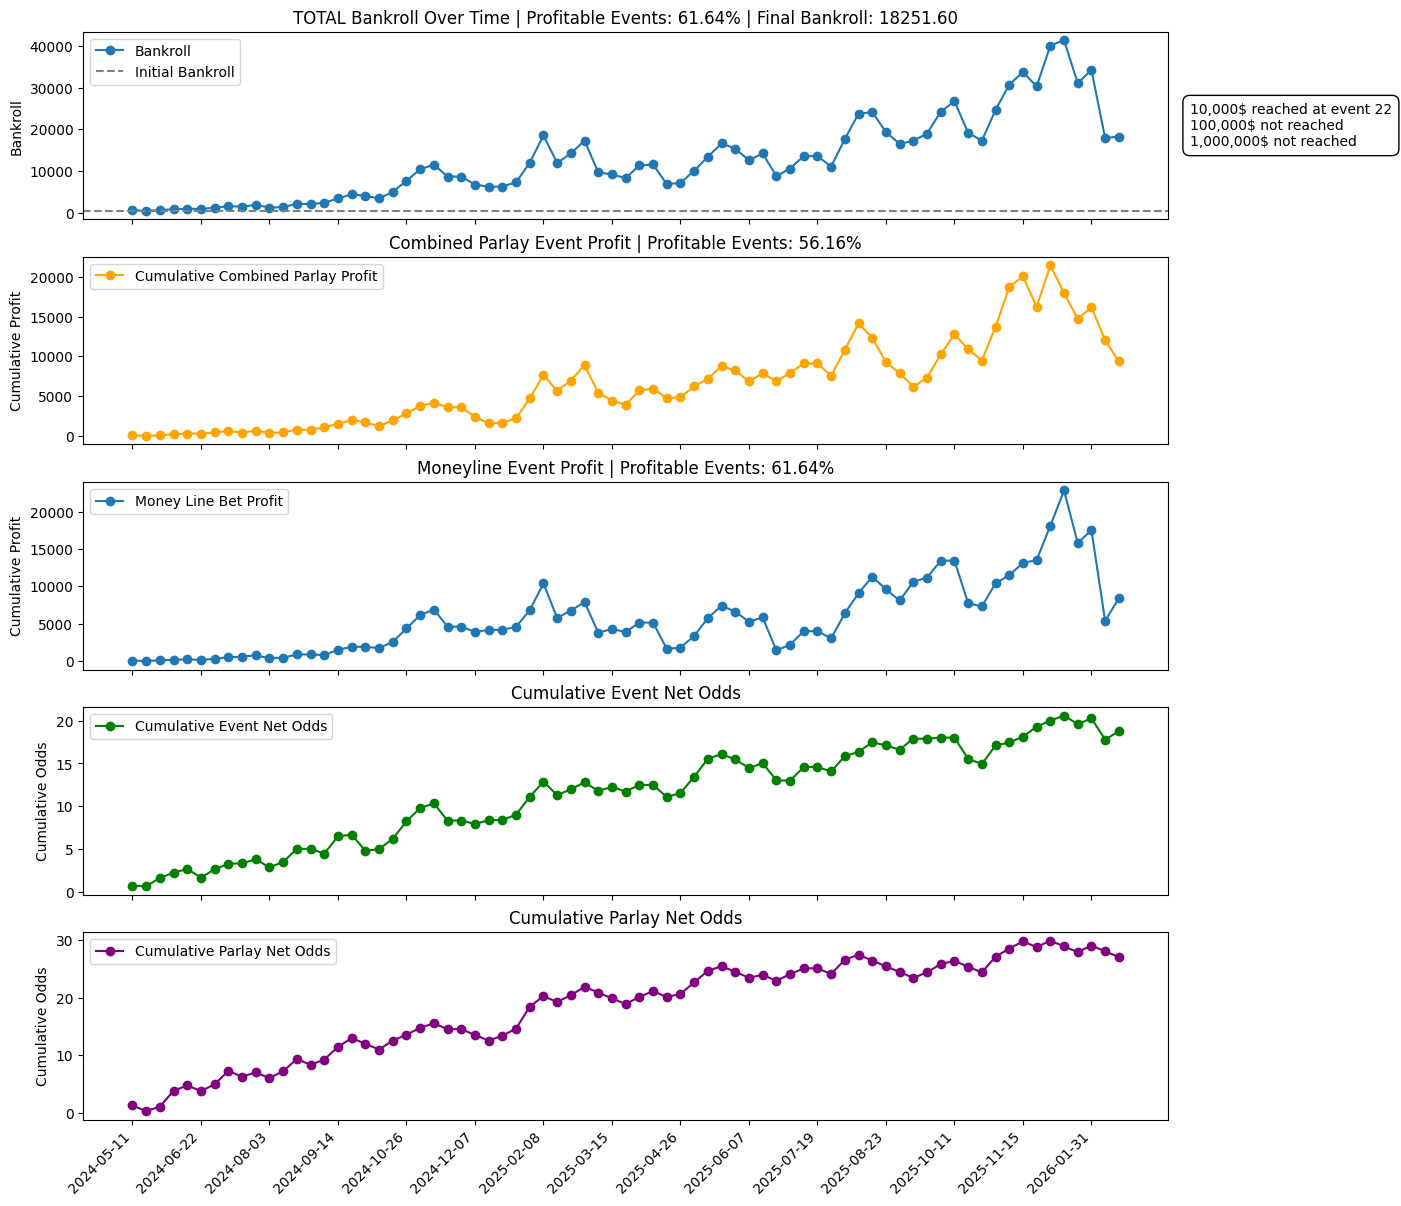

In [ ]:
from ufc_betting.config import settings
from ufc_betting.Models.RiskManagement.open_model_close1_input import opening_model_at_close1
from ufc_betting.BettingStrategy.Backtest.backtest_functions import simulate_kelly
from ufc_betting.BettingStrategy.Backtest.backtest_plots import plot_backtest

# Fixed opening model evaluated with close1 prices, including updated prediction SE.
df_open_at_close1 = opening_model_at_close1()
df_kelly_open_at_close1, df_parlay_open_at_close1 = simulate_kelly(
    df_open_at_close1,
    prob_cols=['proba_blue', 'proba_red'],
    fair_decimal_cols=['dec_fair_close1_blue', 'dec_fair_close1_red'],
    real_decimal_cols=['dec_close1_blue', 'dec_close1_red'],
    pred_winner_col='pred_winner', date_col='date',
    init_bankroll=500, bankroll_floor=100,
    max_drawdown=.4, parlay_mdd=.5, N=250, N_parlay=1490,
    calc_parlay=True, calc_heavy_favorite_parlay=False,
    z=0.5, prediction_se_col='proba_se',moneyline_american_bounds=(-260, 600)
)

plot_fp = settings.data_dir / 'plot_pngs' / 'open_model_close1_prices_kelly_sim.png'
plot_fp.parent.mkdir(parents=True, exist_ok=True)
plot_backtest(df_kelly_open_at_close1, init_bankroll=500, path=str(plot_fp))
df_kelly_open_at_close1.to_csv(settings.data_dir / 'kelly_results' / 'kelly_open_model_close1_prices.csv', index=False)


In [22]:
import pandas as pd 

from ufc_betting.BettingStrategy.Backtest.backtest_functions import simulate_kelly
from ufc_betting.BettingStrategy.Backtest.backtest_plots import plot_backtest

In [ ]:
# https://vegapit.com/article/numerically_solve_kelly_criterion_multiple_simultaneous_bets/
# https://nickyoder.com/kelly-criterion/
# https://www.mma-ai.net/ 

# https://business.columbia.edu/sites/default/files-efs/pubfiles/6343/bayes_kelly.pdf
## Portfolio Choice and the Bayesian Kelly Criterion


Bankroll low on 2023-11-18, replenishing funds
Bankroll low on 2024-02-24, replenishing funds
Bankroll low on 2024-04-27, replenishing funds
Bankroll low on 2024-12-14, replenishing funds
Bankroll low on 2025-04-12, replenishing funds


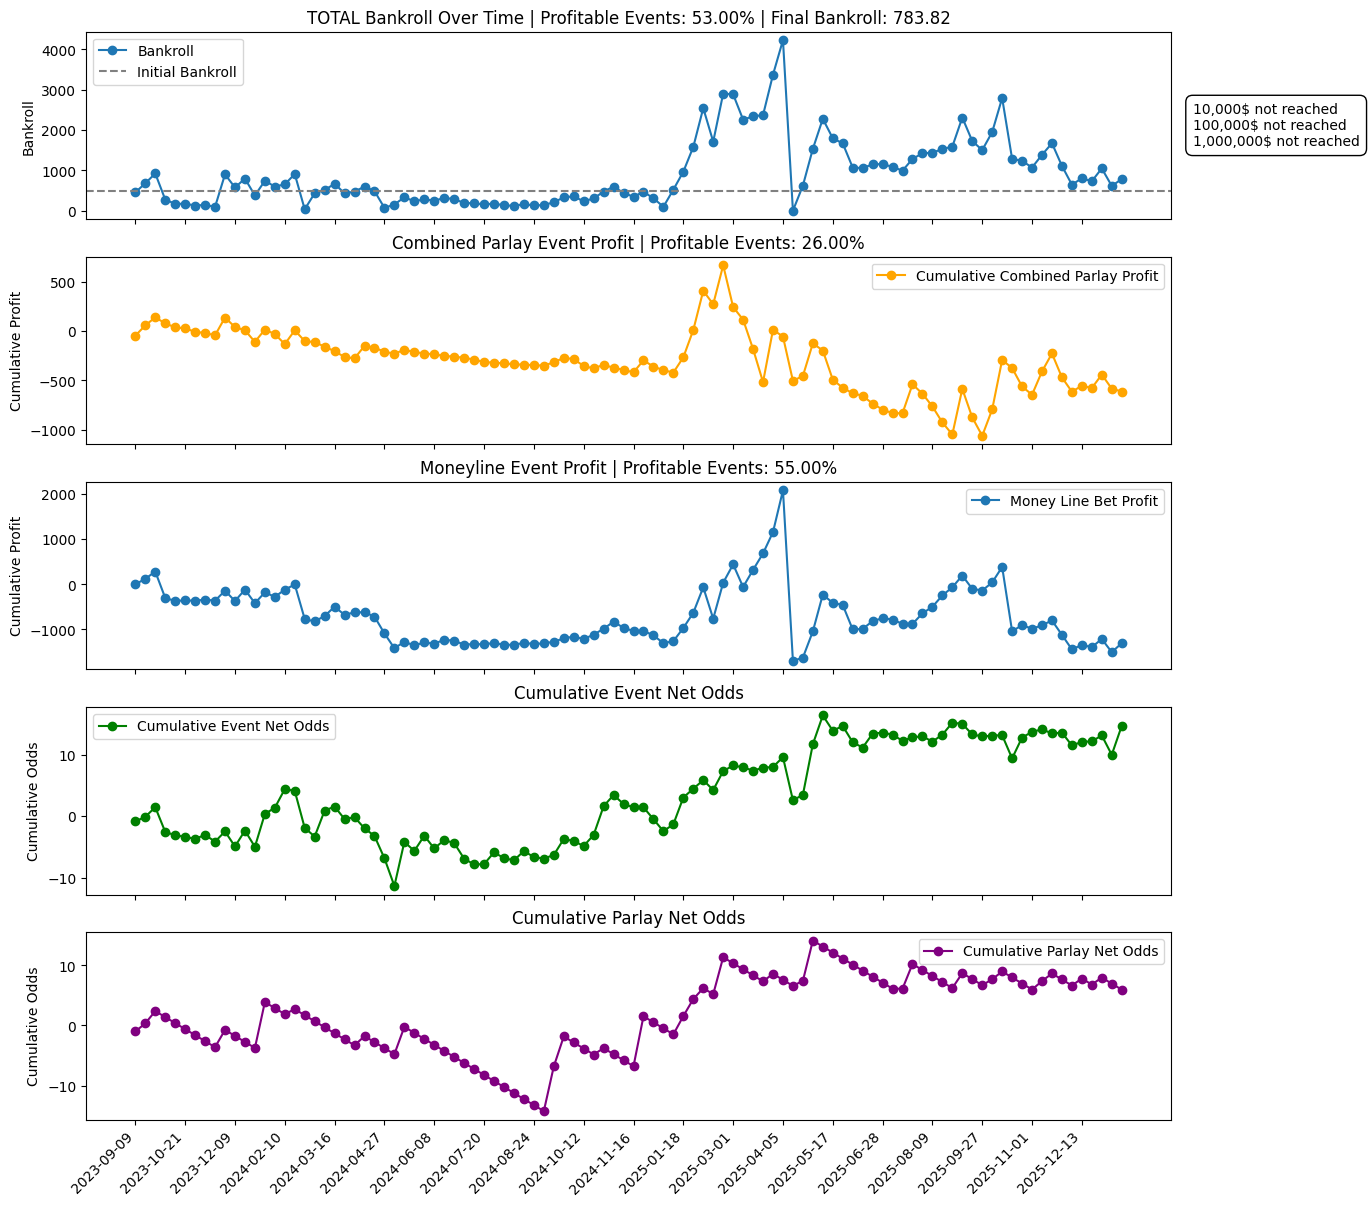

(<Figure size 1400x1600 with 5 Axes>,
 array([<Axes: title={'center': 'TOTAL Bankroll Over Time | Profitable Events: 53.00% | Final Bankroll: 783.82'}, ylabel='Bankroll'>,
        <Axes: title={'center': 'Combined Parlay Event Profit | Profitable Events: 26.00%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Moneyline Event Profit | Profitable Events: 55.00%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Cumulative Event Net Odds'}, ylabel='Cumulative Odds'>,
        <Axes: title={'center': 'Cumulative Parlay Net Odds'}, ylabel='Cumulative Odds'>],
       dtype=object))

In [14]:
import pandas as pd

betting_data = pd.read_csv(
    r"C:\Users\jcmar\my_files\SportsBetting\src"
    r"\ufc_betting\Models\RiskManagement"
    r"\close1_walk_forward_betting_data.csv"
)

monthly_params = pd.read_csv(
    r"C:\Users\jcmar\my_files\SportsBetting\src"
    r"\ufc_betting\Models\RiskManagement"
    r"\close1_walk_forward_monthly_results.csv"
)

df_kelly_close1, df_parlay_close1 = simulate_kelly(
    df_final=betting_data,
    monthly_params=monthly_params,
    use_walk_forward_params=False,
    prob_cols=["proba_blue", "proba_red"],
    fair_decimal_cols=[
        "dec_fair_close1_blue",
        "dec_fair_close1_red",
    ],
    real_decimal_cols=[
        "dec_close1_blue",
        "dec_close1_red",
    ],
    pred_winner_col="pred_winner",
    prediction_se_col="proba_se",
    date_col="date",
    init_bankroll=500,
    bankroll_floor=100,
    calc_parlay=True,
    calc_heavy_favorite_parlay=False,
    test_other_ev=True,
    test_bankroll_scaler=False,
)
plot_backtest(df_kelly_close1, 500, path=None)


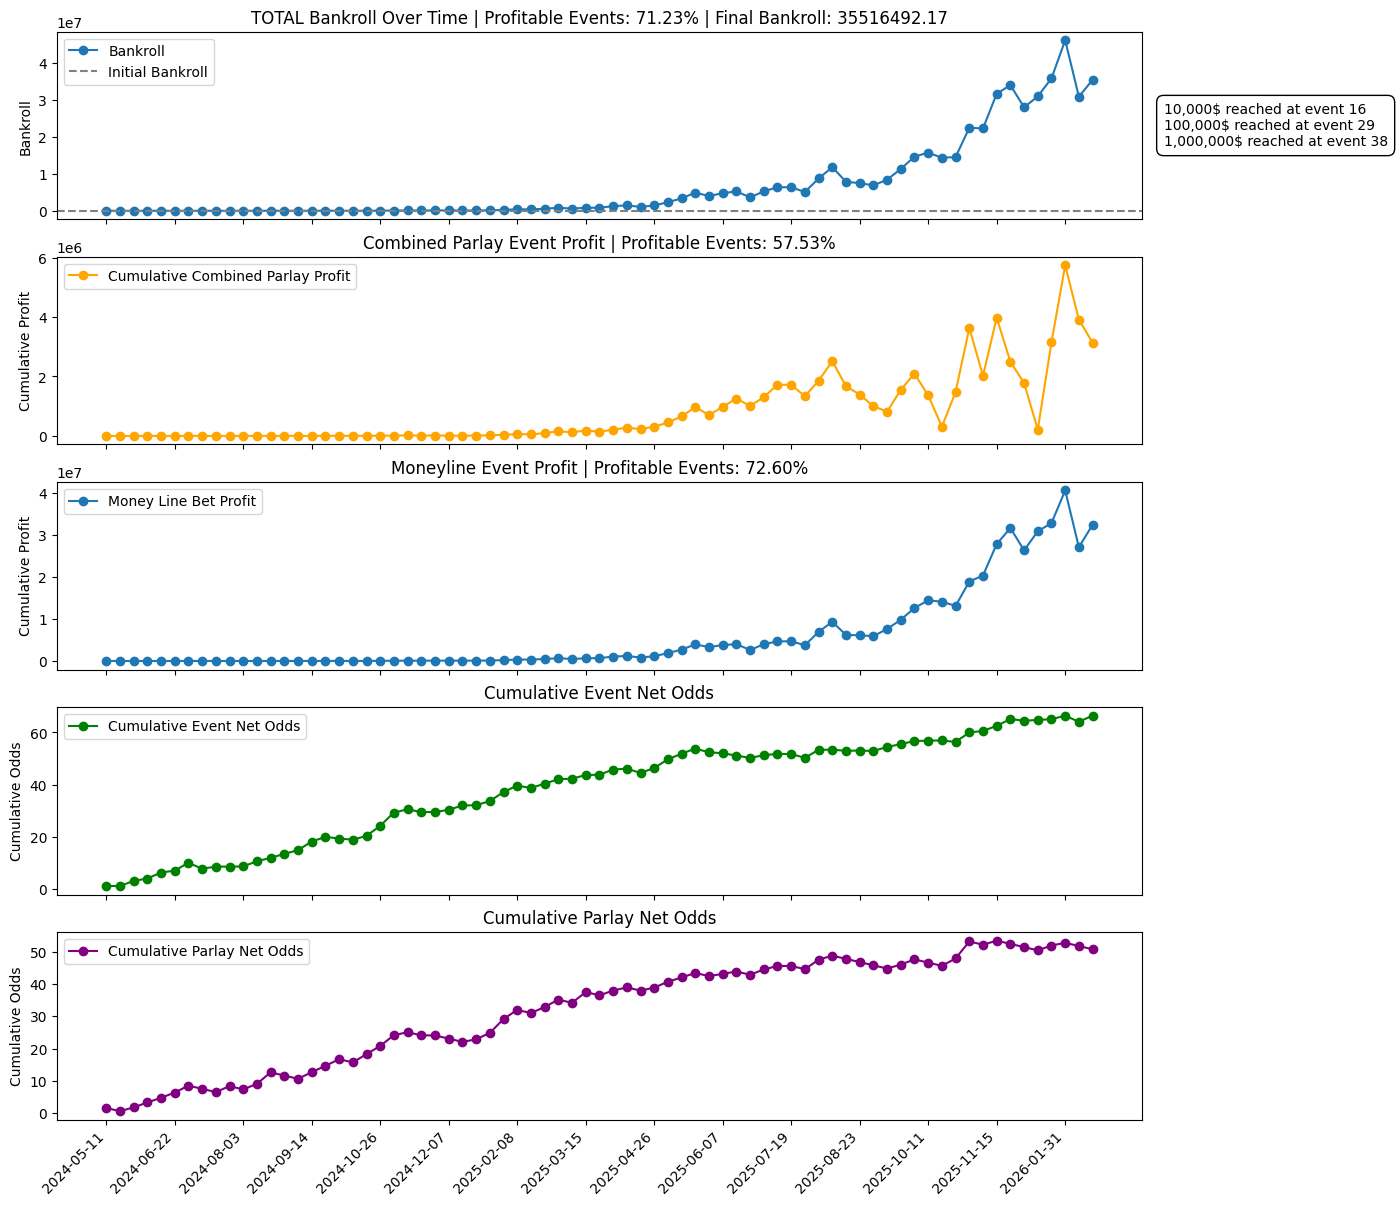

In [25]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']  # your decimal odds columns
real_decimal_odds = ['dec_open_blue', 'dec_open_red']

df_kelly, df_parlay, = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    max_drawdown=.6,
    parlay_mdd=.22,
    N=327,
    N_parlay=1289,
    calc_parlay=True,
    test_other_ev=False
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_kelly_sim.png'
plot_backtest(df_kelly, 500, path=plot_fp)
# plot_event_odds_stats(df_kelly)

# x_vars = ['mu_portfolio', 'sharpe_portfolio', 'portfolio_sigma']
# y_var = 'event_net_odds'
# kelly_analysis(df_kelly, x_vars, y_var)

df_kelly.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_open.csv')

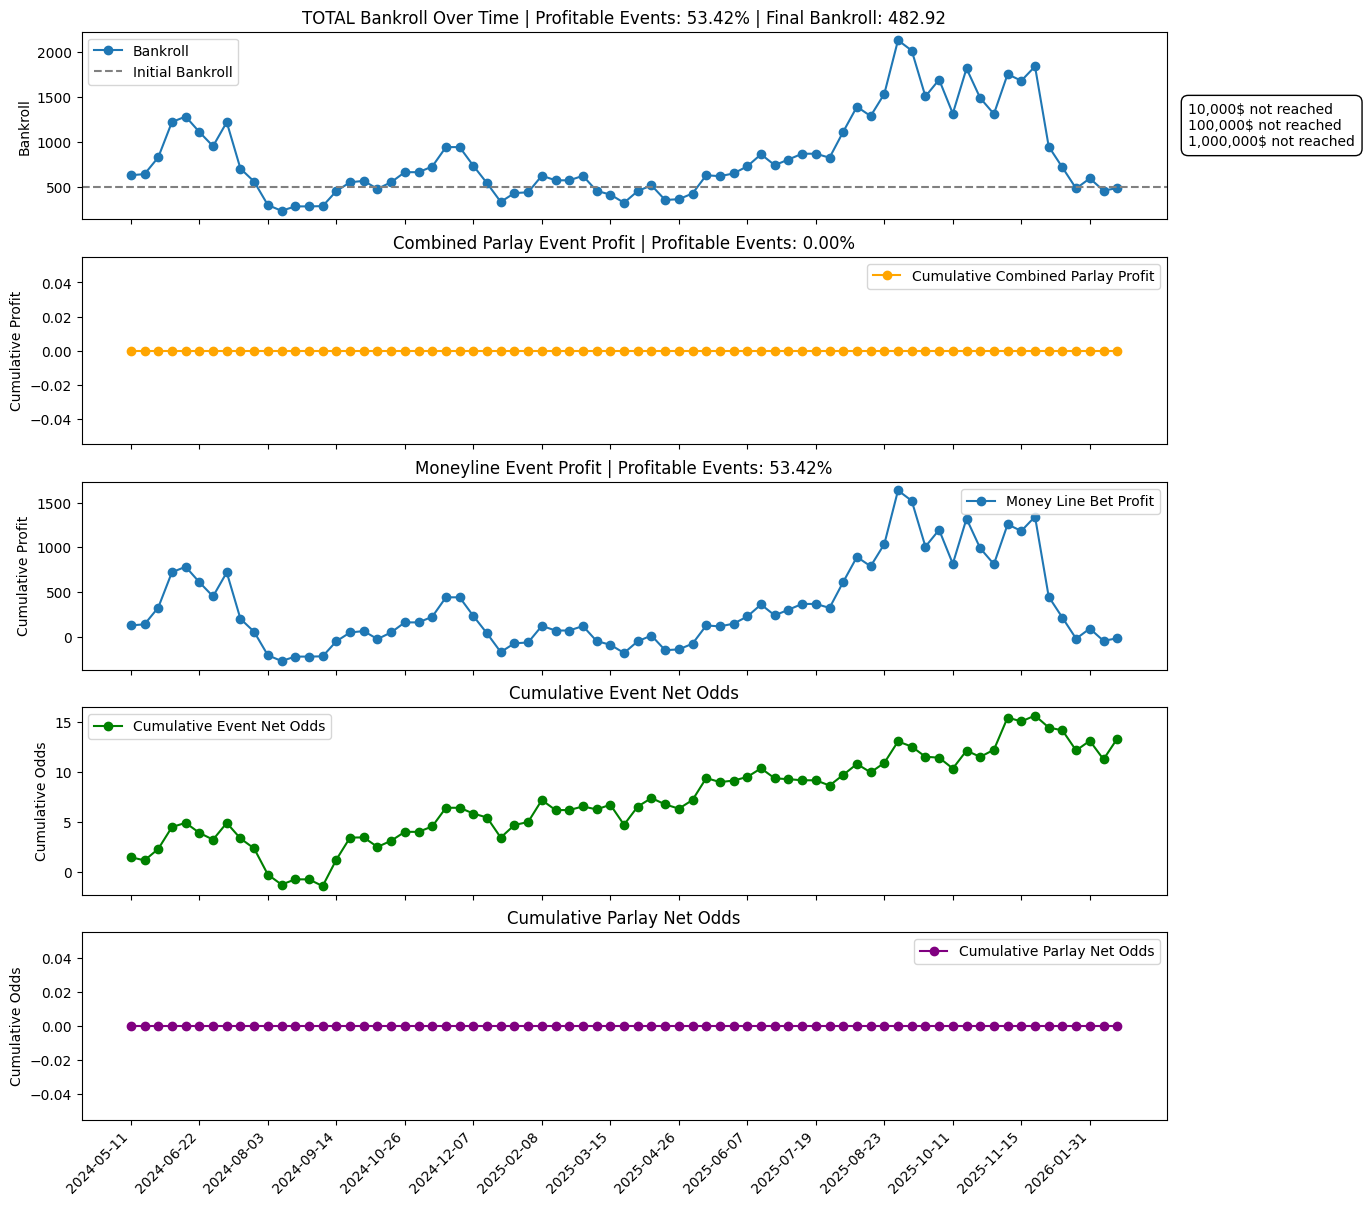

(<Figure size 1400x1600 with 5 Axes>,
 array([<Axes: title={'center': 'TOTAL Bankroll Over Time | Profitable Events: 53.42% | Final Bankroll: 482.92'}, ylabel='Bankroll'>,
        <Axes: title={'center': 'Combined Parlay Event Profit | Profitable Events: 0.00%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Moneyline Event Profit | Profitable Events: 53.42%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Cumulative Event Net Odds'}, ylabel='Cumulative Odds'>,
        <Axes: title={'center': 'Cumulative Parlay Net Odds'}, ylabel='Cumulative Odds'>],
       dtype=object))

In [33]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly, df_parlay, = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    max_drawdown=.4,
    parlay_mdd=.22,
    N=200,
    N_parlay=1289,
    calc_parlay=False,
    test_other_ev=False
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_backtest(df_kelly, 500, path=None)

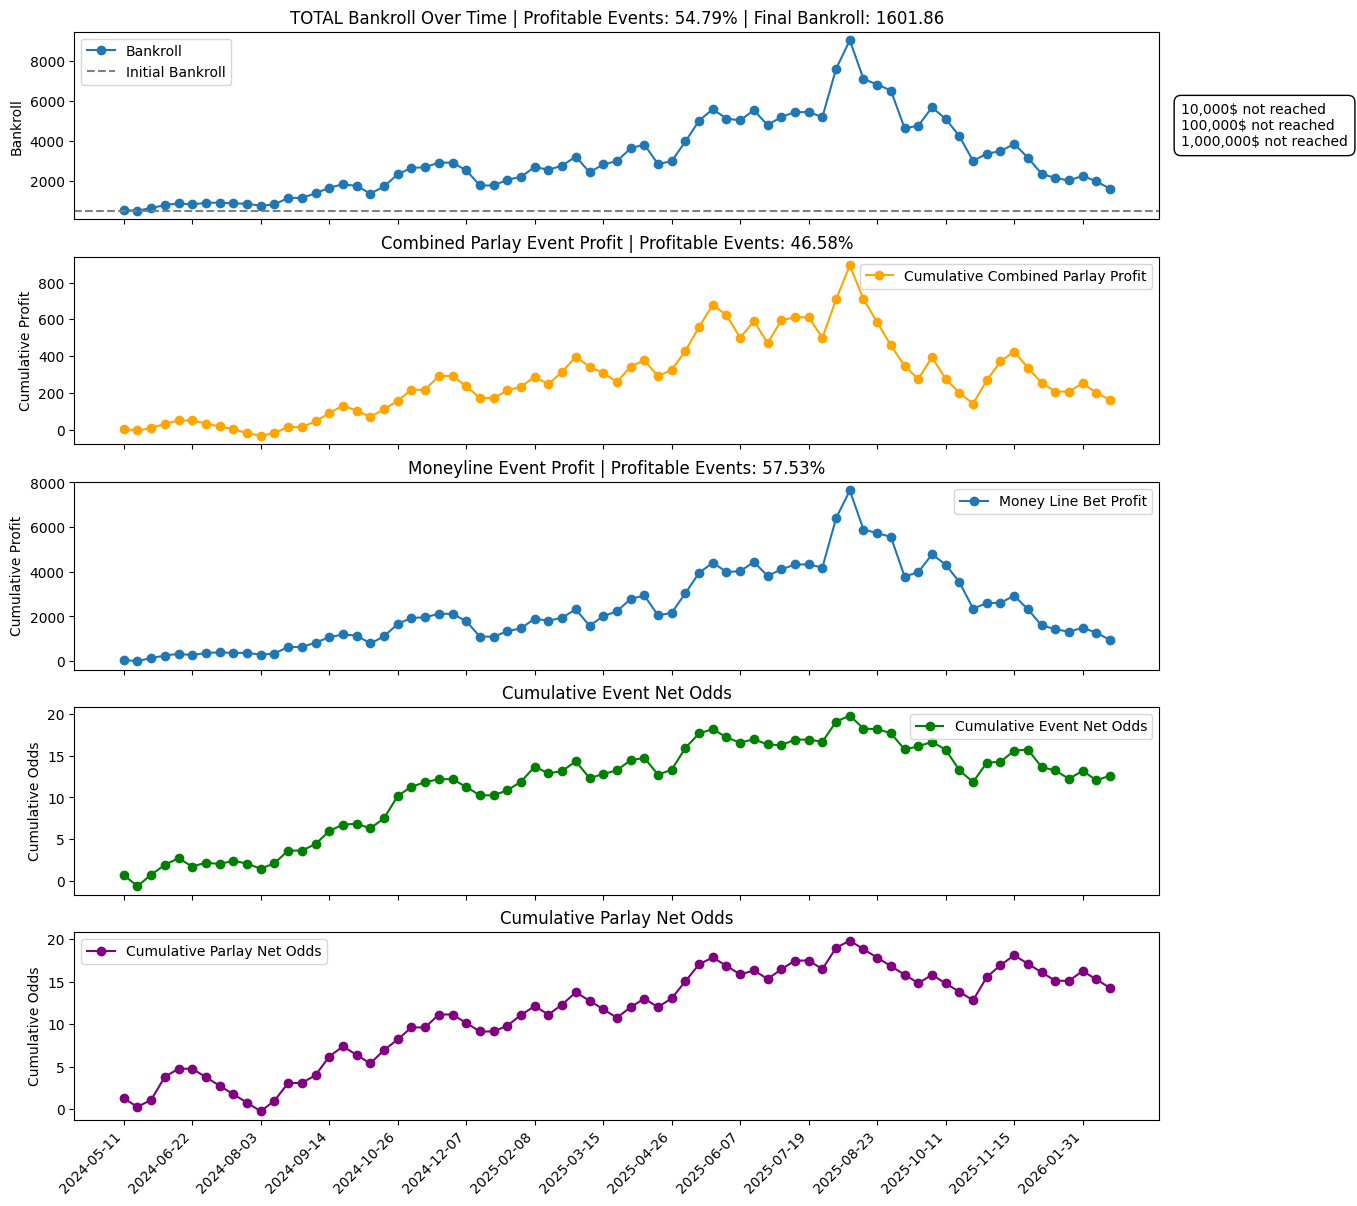

In [4]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly1, df_kelly1_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    max_drawdown=.8,
    parlay_mdd=.1,
    N=250,
    N_parlay=1490,
    calc_parlay=True,
    calc_heavy_favorite_parlay=False,
    z=0.5,
    prediction_se_col='proba_se'
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_kelly_sim.png'
plot_backtest(df_kelly1, 500, path=plot_fp)

df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close1.csv')

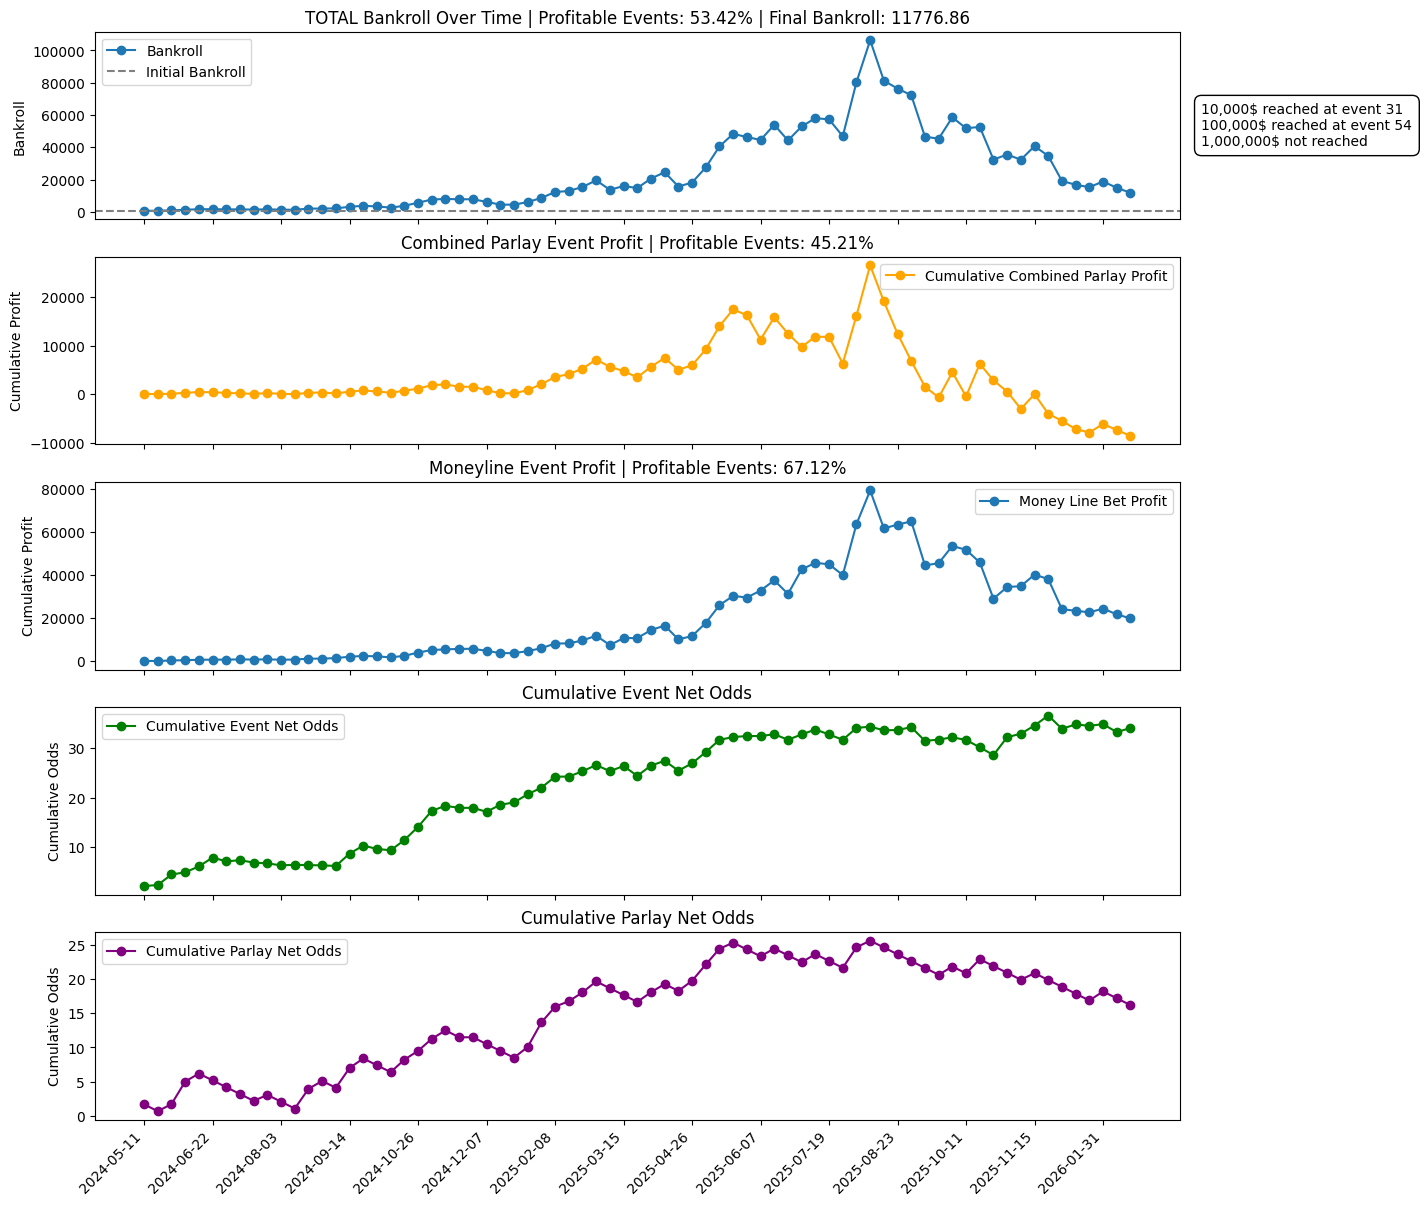

In [11]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']

df_kelly1, df_kelly1_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    max_drawdown=.58,
    parlay_mdd=.4,
    N=890,
    N_parlay=1490,
    calc_parlay=True,
    z=0.5,
    prediction_se_col='proba_se'
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_kelly_sim.png'
plot_backtest(df_kelly1, 500, path=plot_fp)

df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close2.csv')

Bankroll low on 2024-04-27, replenishing funds


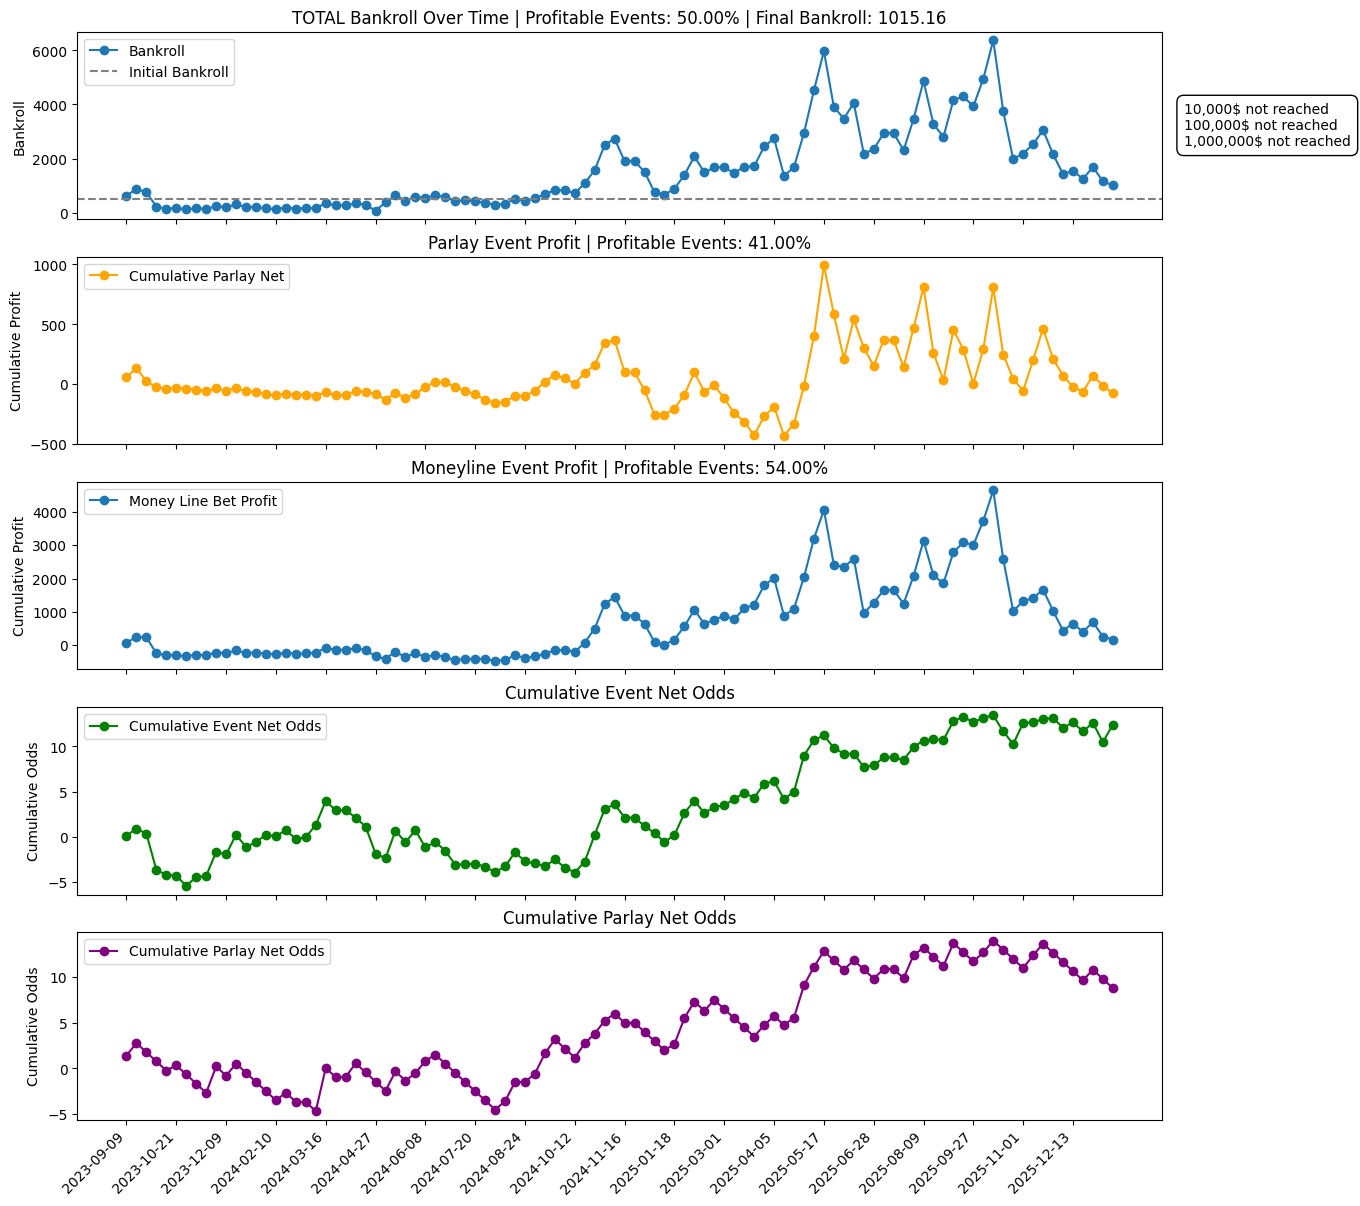

In [2]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\src\ufc_betting\Models\RiskManagement\close1_walk_forward_betting_data.csv')


prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']
df_kelly2, df_kelly2_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    max_drawdown=.58,
    parlay_mdd=.23,
    N=685,
    N_parlay=201,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_kelly_sim.png'
plot_backtest(df_kelly2, 500, path=plot_fp)

df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close1.csv')

Opening model at close1 prices: 222 fights


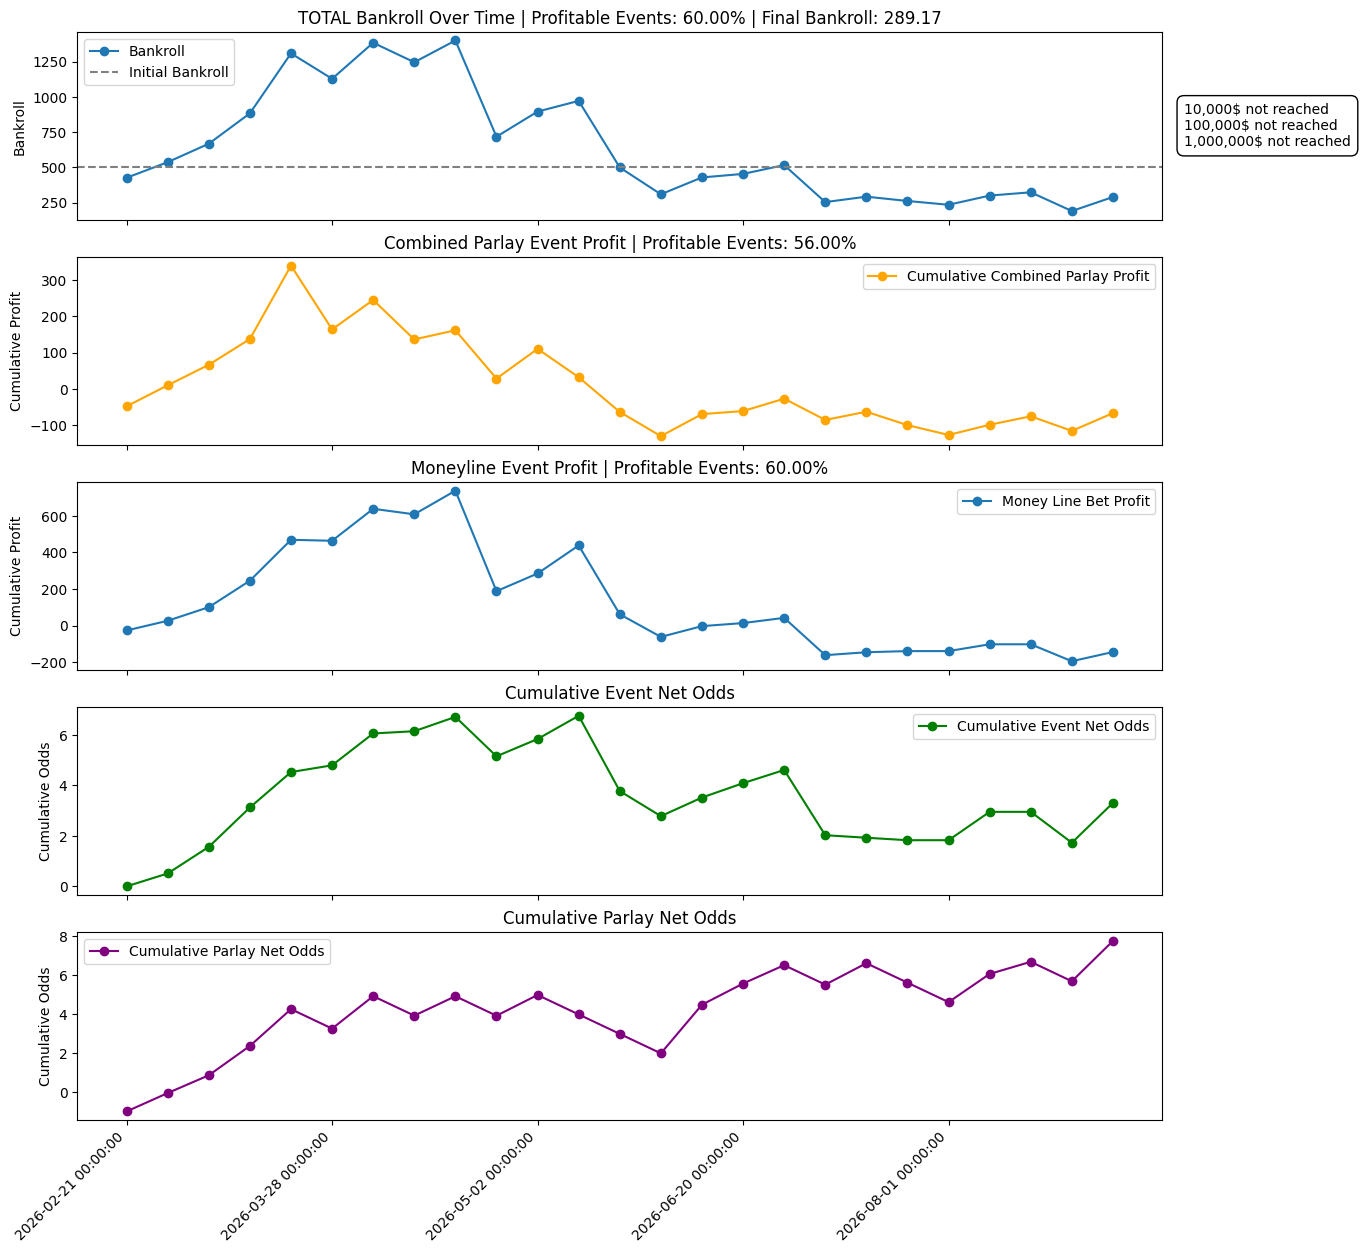

Opening model at close2 prices: 222 fights


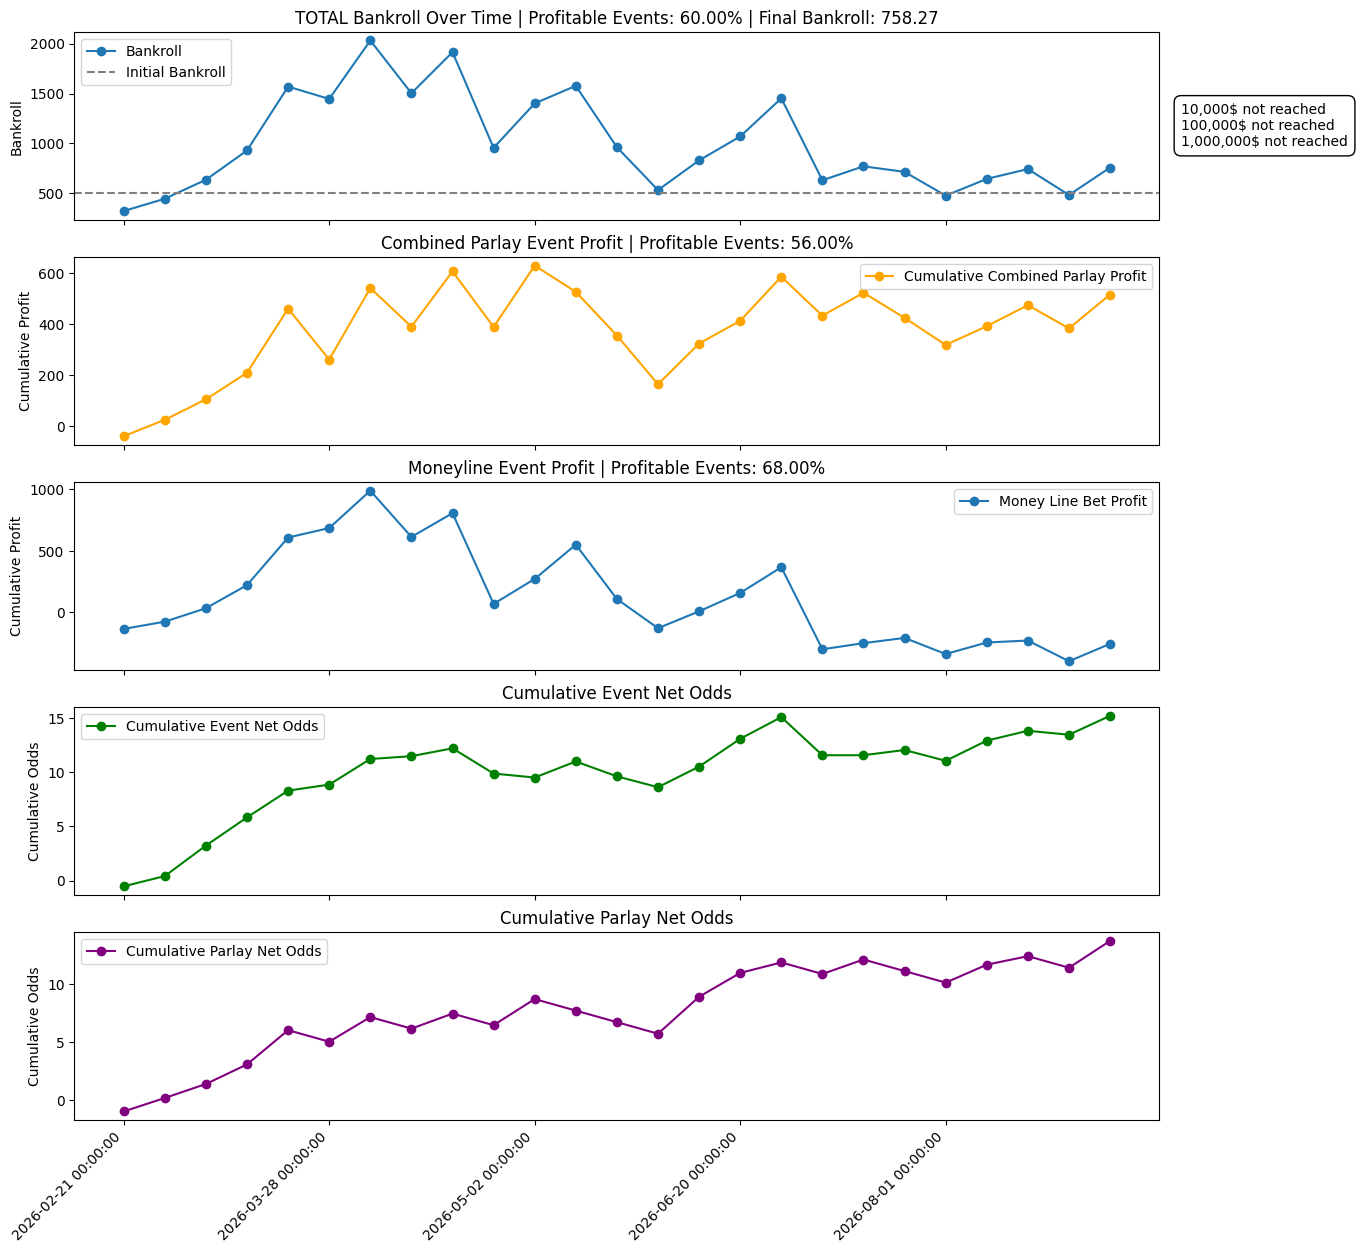

In [14]:
import pandas as pd 
from ufc_betting.config import settings
from ufc_betting.BettingStrategy.Backtest.backtest_functions import simulate_kelly
from ufc_betting.BettingStrategy.Backtest.backtest_plots import plot_backtest

prediction_path = (
    settings.non_merged_features_dir
    / "open_model_close1_close2_results.csv"
)
if not prediction_path.is_file():
    import importlib
    from ufc_betting.Models.RiskManagement import build_non_merged_open_predictions

    print(f"{prediction_path.name} was not found; generating it now...")
    generator = importlib.reload(build_non_merged_open_predictions)
    _, generated_prediction_path = generator.run()
    if generated_prediction_path != prediction_path:
        raise RuntimeError(
            f"Generator wrote {generated_prediction_path}, expected {prediction_path}"
        )

df_open_model_predictions = pd.read_csv(prediction_path)
df_open_model_predictions["date"] = pd.to_datetime(
    df_open_model_predictions["date"], errors="raise"
).dt.normalize()

required_stages = {"close1", "close2"}
available_stages = set(df_open_model_predictions["odds_type"].dropna())
missing_stages = required_stages - available_stages
if missing_stages:
    raise ValueError(
        f"Prediction CSV is missing odds types: {sorted(missing_stages)}"
    )

open_model_backtests = {}
for odds_type in ["close1", "close2"]:
    backtest_input = (
        df_open_model_predictions
        .loc[df_open_model_predictions["odds_type"].eq(odds_type)]
        .sort_values(["date", "fighter_red", "fighter_blue"])
        .reset_index(drop=True)
    )
    df_kelly_result, df_parlay_result = simulate_kelly(
        backtest_input,
        prob_cols=["proba_blue", "proba_red"],
        fair_decimal_cols=[
            f"dec_fair_{odds_type}_blue",
            f"dec_fair_{odds_type}_red",
        ],
        real_decimal_cols=[
            f"dec_{odds_type}_blue",
            f"dec_{odds_type}_red",
        ],
        pred_winner_col="pred_winner",
        date_col="date",
        init_bankroll=500,
        bankroll_floor=100,
        max_drawdown=.4,
        parlay_mdd=.5,
        N=250,
        N_parlay=1490,
        calc_parlay=True,
        calc_heavy_favorite_parlay=False,
        z=.5,
        prediction_se_col="proba_se",
        moneyline_american_bounds=(-260, 300),
    )
    open_model_backtests[odds_type] = {
        "input": backtest_input,
        "kelly": df_kelly_result,
        "parlay": df_parlay_result,
    }
    print(f"Opening model at {odds_type} prices: {len(backtest_input):,} fights")
    plot_backtest(df_kelly_result, init_bankroll=500, path=None)

df_kelly_open_at_close1 = open_model_backtests["close1"]["kelly"]
df_parlay_open_at_close1 = open_model_backtests["close1"]["parlay"]
df_kelly_open_at_close2 = open_model_backtests["close2"]["kelly"]
df_parlay_open_at_close2 = open_model_backtests["close2"]["parlay"]

Bankroll low on 2026-07-25, replenishing funds


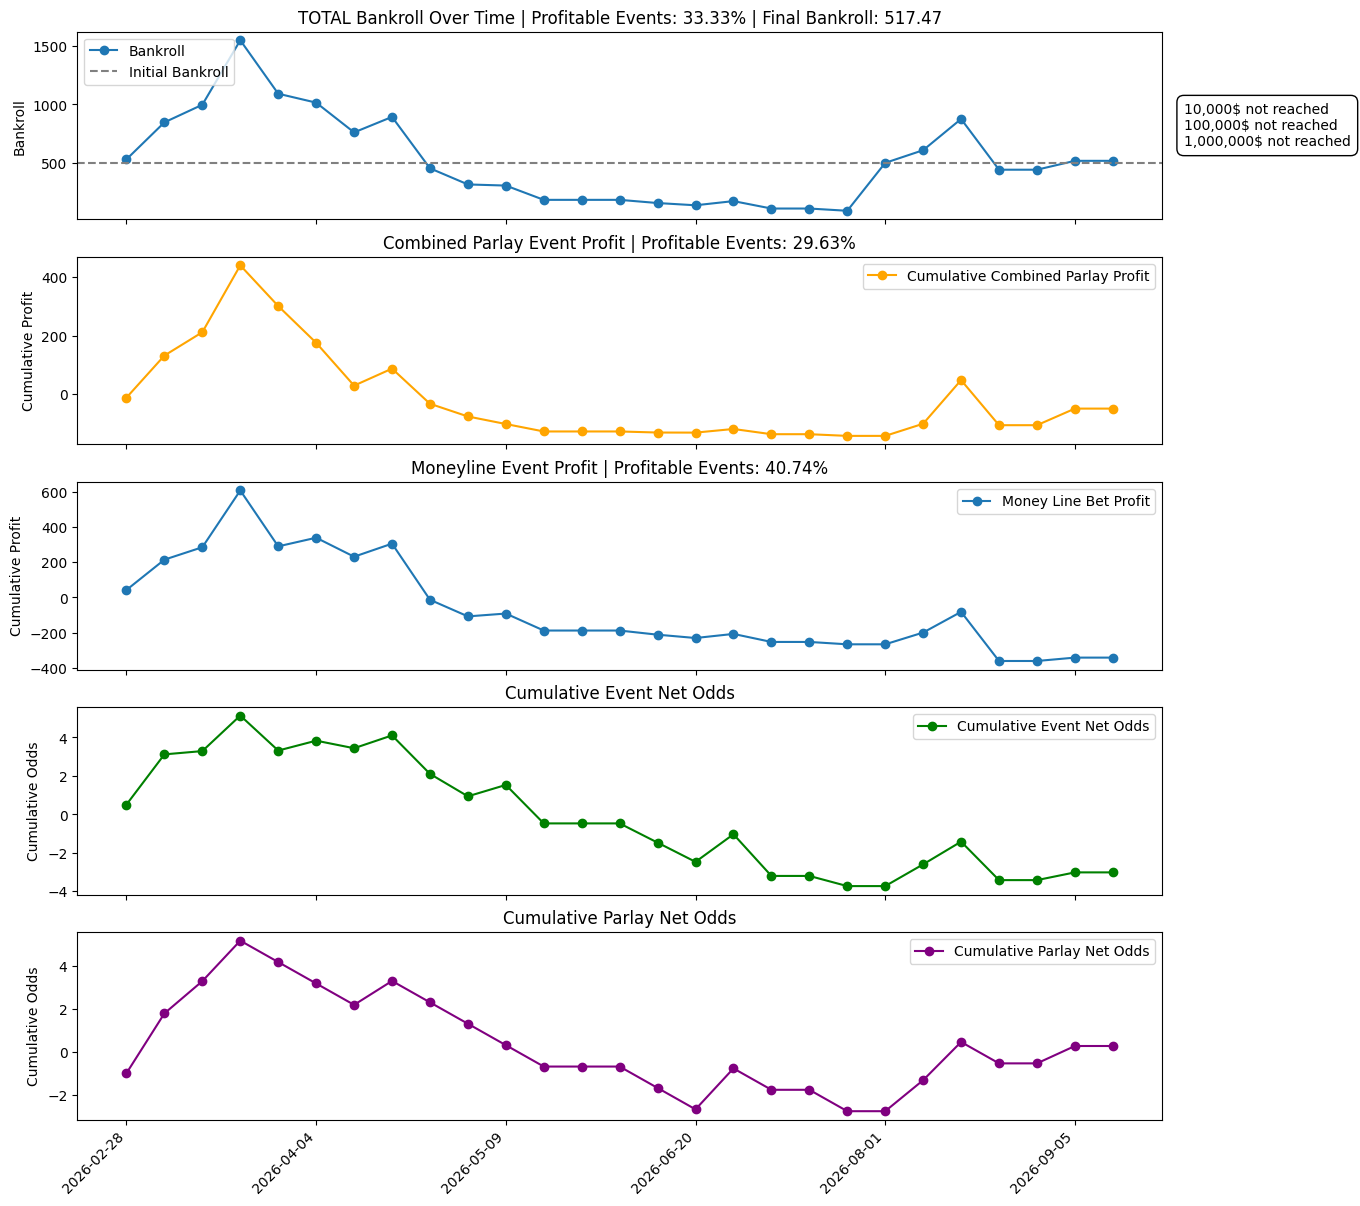

(<Figure size 1400x1600 with 5 Axes>,
 array([<Axes: title={'center': 'TOTAL Bankroll Over Time | Profitable Events: 33.33% | Final Bankroll: 517.47'}, ylabel='Bankroll'>,
        <Axes: title={'center': 'Combined Parlay Event Profit | Profitable Events: 29.63%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Moneyline Event Profit | Profitable Events: 40.74%'}, ylabel='Cumulative Profit'>,
        <Axes: title={'center': 'Cumulative Event Net Odds'}, ylabel='Cumulative Odds'>,
        <Axes: title={'center': 'Cumulative Parlay Net Odds'}, ylabel='Cumulative Odds'>],
       dtype=object))

In [18]:
df_open_at_close1 = pd.read_csv(
    r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_set_data_open_with_close1.csv'
)
df_kelly_open_at_close1, df_parlay_open_at_close1 = simulate_kelly(
    df_open_at_close1,
    prob_cols=['proba_blue', 'proba_red'],
    fair_decimal_cols=['dec_fair_close1_blue', 'dec_fair_close1_red'],
    real_decimal_cols=['dec_close1_blue', 'dec_close1_red'],
    pred_winner_col='pred_winner', date_col='date',
    init_bankroll=500, bankroll_floor=100,
    max_drawdown=.4, parlay_mdd=.5, N=250, N_parlay=1490,
    calc_parlay=True, calc_heavy_favorite_parlay=False,
    z=0.5, prediction_se_col='proba_se',moneyline_american_bounds=(-260, 600)
)


plot_backtest(df_kelly_open_at_close1, init_bankroll=500, path=None)


In [5]:
df_kelly_open_at_close1['date'].nunique()

25

In [4]:
df_kelly_open_at_close1.sort_values(by='bankroll_pct_change',ascending=True)[['fighter_red','fighter_blue','date','pred_winner','bankroll_pct_change']].head(20)

,fighter_red,fighter_blue,date,pred_winner,bankroll_pct_change
80,rafa garcia,alexander hernandez,2026-04-25,1,-0.443979
81,norma dumont,joselyne edwards,2026-04-25,1,-0.443979
82,montel jackson,raoni barcelos,2026-04-25,1,-0.443979
83,marcus buchecha,ryan spann,2026-04-25,1,-0.443979
84,jafel filho,cody durden,2026-04-25,1,-0.443979
85,jackson mcvey,sedriques dumas,2026-04-25,1,-0.443979
86,aljamain sterling,youssef zalal,2026-04-25,0,-0.443979
87,mayra bueno silva,michelle montague,2026-04-25,0,-0.443979
78,talita alencar,julia polastri,2026-04-25,0,-0.443979
79,rodolfo vieira,eric mcconico,2026-04-25,1,-0.443979


In [8]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive

np.float64(0.5)

https://wayback.archive-it.org/5456/20240920160238/https://www.eecs.harvard.edu/cs286r/courses/fall12/papers/Thorpe_KellyCriterion2007.pdf

https://medium.com/raposa-technologies/how-to-use-python-and-the-kelly-criterion-to-optimize-your-stock-portfolio-bb6e43df50c2



In [ ]:
https://web3.arxiv.org/abs/2207.14124?utm_source=chatgpt.com

https://pubmed.ncbi.nlm.nih.gov/35205582/

https://summit.sfu.ca/item/34958?utm_source=chatgpt.com


https://www.glicko.net/glicko/glicko2.pdf

https://www.glicko.net/glicko.html

https://ojs.aaai.org/index.php/AIIDE/article/view/5233


https://arxiv.org/abs/2303.16741?utm_source=chatgpt.com

https://opisthokonta.net/?cat=48


https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

